# Carga de los datos
Fuente: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

In [31]:
# importación de librerias 
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.impute import KNNImputer
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn import svm
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import fbeta_score, make_scorer
import torch
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, fbeta_score)

# SRC


# Agregar la carpeta src al path
sys.path.append(os.path.abspath(".."))

# Intentar importar nuevamente
from src.utilits.models import pipelines, calculate_metrics, TorchClassifier
from src.utilits.hyperparam_op import param_grids

In [2]:
# Importar Dataset como dataframe de pandas

path = "../data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Eliminamos la columna id

df = df.drop(columns=["id"])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# EDA

In [4]:
print(
    df["ever_married"].unique(), "\n",
    df["work_type"].unique(),"\n",
    df["Residence_type"].unique(),"\n",
    df["smoking_status"].unique()
)

['Yes' 'No'] 
 ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked'] 
 ['Urban' 'Rural'] 
 ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


Vemos que hay varias columnas en el dataset:
- gender: índica el género de los pacientes (Male, Female, Other).
- age: edad
- hypertension: variable categórica de si presentan hipertensión.
- heart_disease: variable categórica de si presentan alguna enfermedad cardíaca.
- ever_married: casado alguna vez ['Yes' 'No']
- work_type: tipo de empleo ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
- Residence_type: tipo de residencia ['Urban' 'Rural']
- avg_glucose_level: nivel de glucosa en sangre
- bmi: indice de masa corporal
- smoking_status: estado de fumar ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
- stroke: variable objetivo: ictus sí o no.

## Análisis univariante

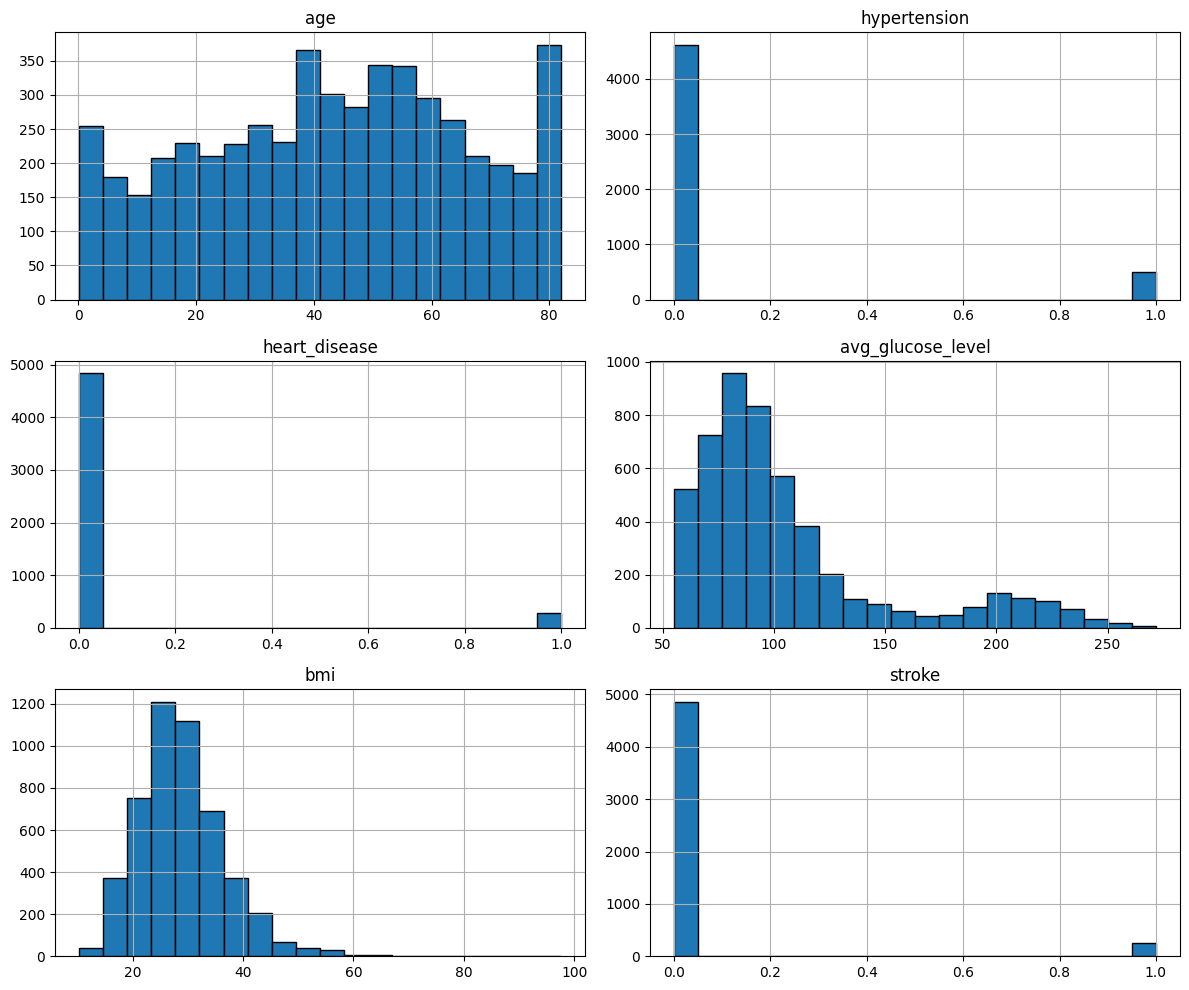

In [5]:
# Crear histogramas para todas las variables
df.hist(figsize=(12, 10), bins=20, edgecolor='black')

# Ajustar el diseño y mostrar los gráficos
plt.tight_layout()
plt.show()

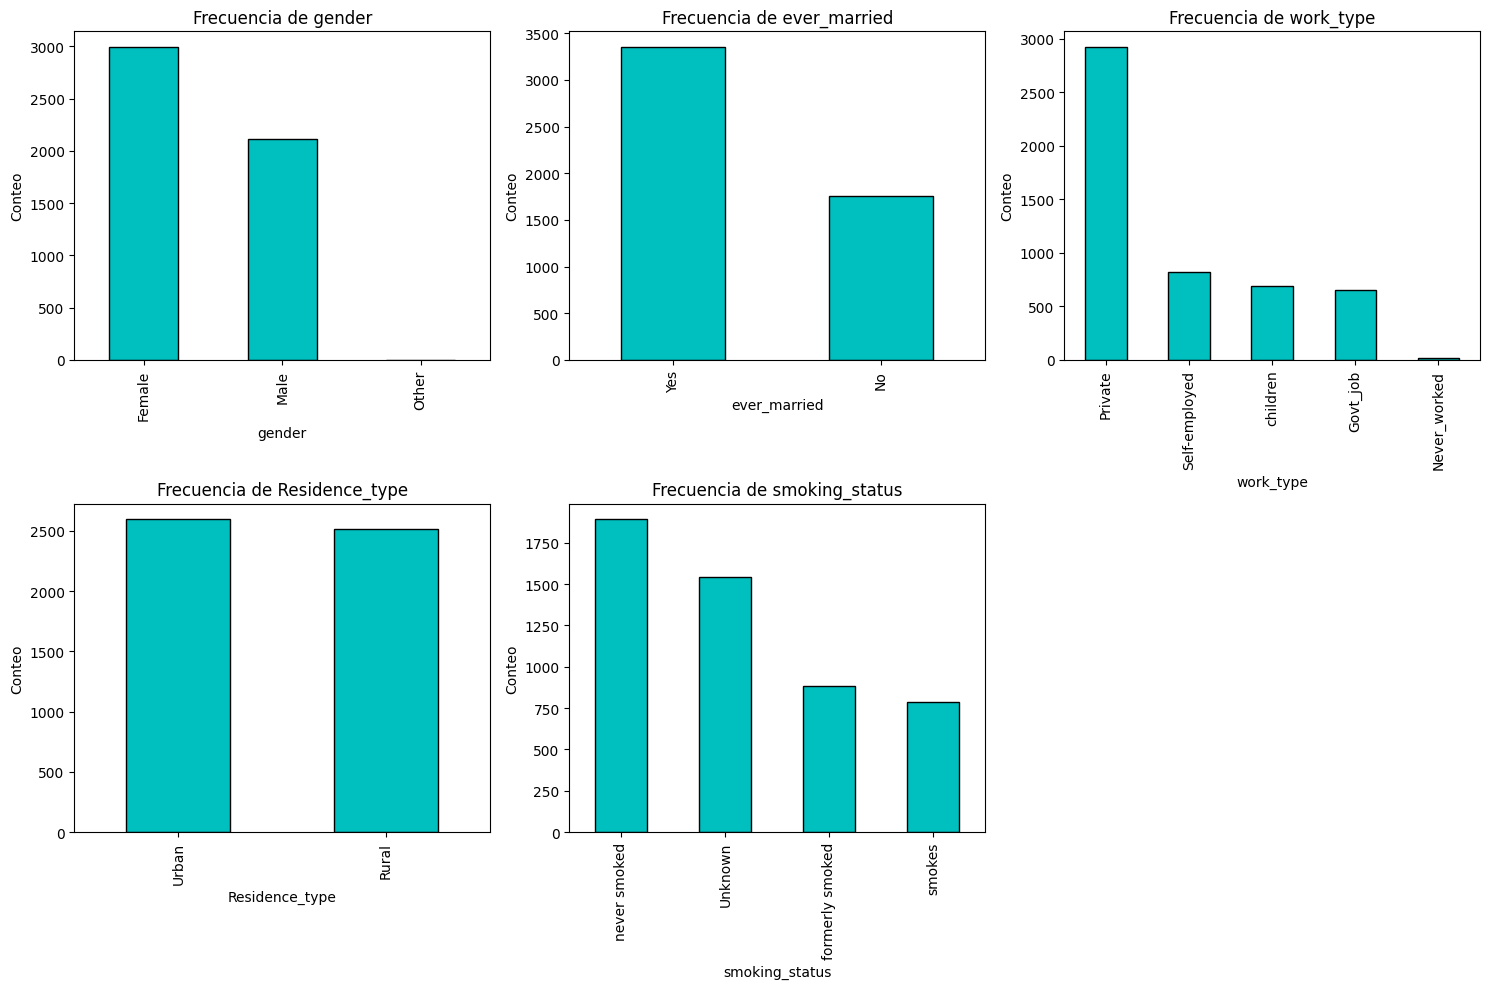

In [6]:
# Identificar variables categóricas
categorical_vars = df.select_dtypes(include=['object']).columns

# Definir tamaño de la malla (3 columnas y filas dinámicas según la cantidad de variables categóricas)
num_vars = len(categorical_vars)
cols = 3  # Número de columnas
rows = (num_vars // cols) + (num_vars % cols > 0)  # Calcular número de filas

# Crear la figura con subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5 * rows))

# Aplanar el array de ejes si es necesario
axes = axes.flatten()

# Graficar cada variable categórica en un bar plot
for i, col in enumerate(categorical_vars):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='c', edgecolor='black')
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteo')

# Ocultar los ejes vacíos si hay menos gráficos que espacios en la malla
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Lo más importante a inferir de estos gráficos es que contamos con muy pocos casos de stroke = 1, es decir, tenemos un desbalanceo de las clases. Será necesario aplicar alguna técnica como el sobremuestreo de la clase  minoritaria para que los modelos actuen de manera correcta.

## Analisis Bivariado
Veamos la relación entre las características y la variable objetivo.

In [7]:
numeric_columns = ['age', 'bmi', 'avg_glucose_level']
categorical_columns = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']

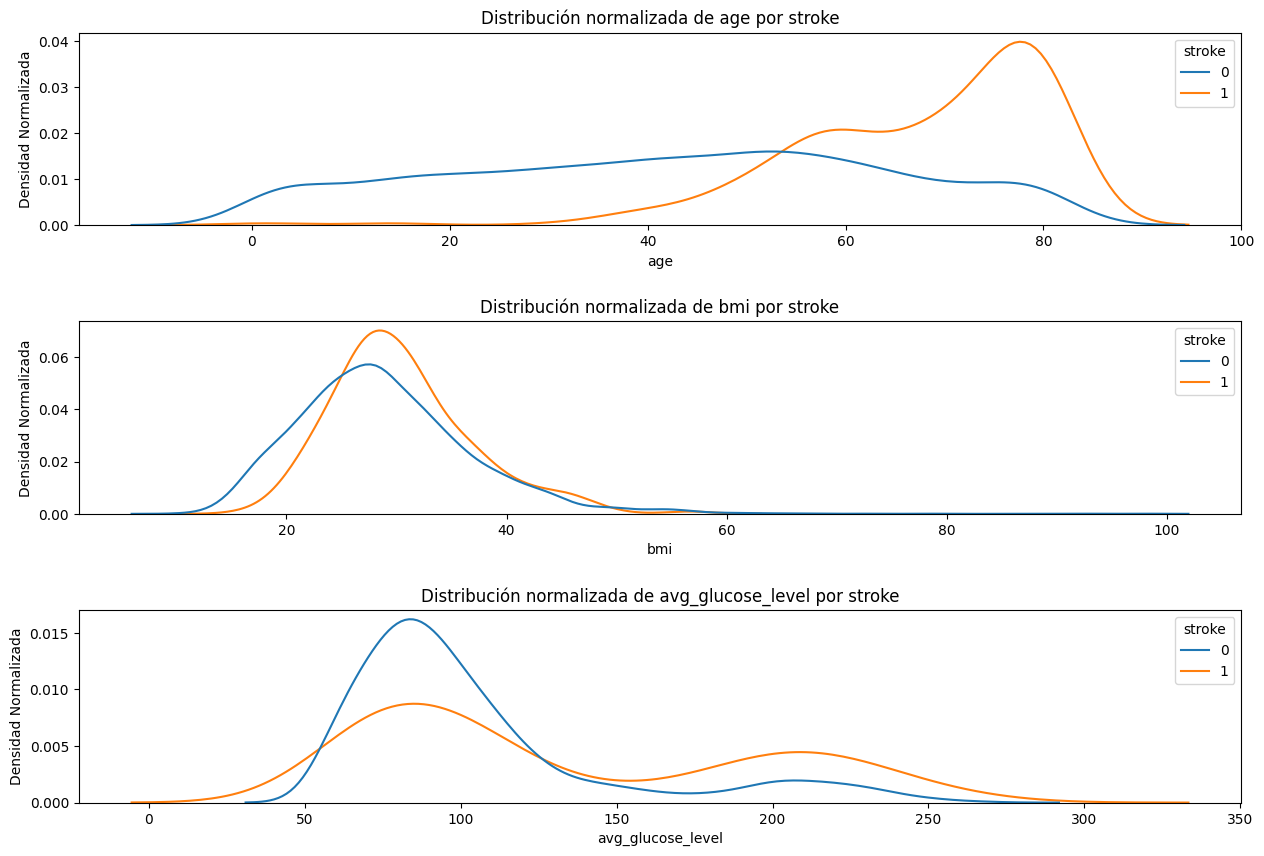

In [8]:
# Crear la figura y ejes
fig, ax = plt.subplots(len(numeric_columns), 1, figsize=(15, 10))

plt.subplots_adjust(hspace=0.5)

# Generar gráficos KDE normalizados dentro de cada categoría de stroke
for i, col in enumerate(numeric_columns):
    sns.kdeplot(x=df[col], hue=df['stroke'], data=df, multiple="layer", common_norm=False, ax=ax[i])
    ax[i].set_title(f'Distribución normalizada de {col} por stroke')
    ax[i].set_ylabel("Densidad Normalizada")

plt.show()

In [9]:
# Contar los casos donde 'age' < 30 y 'stroke' = 1
num_strokes_under_30 = df[(df['age'] < 30) & (df['stroke'] == 1)].shape[0]

# Mostrar el resultado
print(f"Número de casos de stroke con edad < 30: {num_strokes_under_30}")

# Obtener las edades de los casos donde 'age' < 20 y 'stroke' = 1
ages_strokes_under_30 = df.loc[(df['age'] < 30) & (df['stroke'] == 1), 'age']

# Mostrar las edades
print("Edades de personas con stroke y edad < 30:")
print(ages_strokes_under_30.tolist())  # Convertir a lista para mejor legibilidad




Número de casos de stroke con edad < 30: 2
Edades de personas con stroke y edad < 30:
[1.32, 14.0]


Vemos que, claramente la edad es un factor de riesgo, con menos de 30 hay 2 casos de ictus, mientras que la glucosa en sangre y el bmi no presentan a simple vista diferencias. Realizaremos un test de correlación de Pearson y un test  U de Mann-Whitney para saber si presentan una fuerte correlación y si existe una diferencia estadísticamente significativa entre ambas variables.


In [10]:
# Calcular la correlación de Pearson
correlation = df[['avg_glucose_level', 'bmi', 'stroke']].corr()
print(correlation['stroke'])


avg_glucose_level    0.131945
bmi                  0.042374
stroke               1.000000
Name: stroke, dtype: float64


In [11]:
# Prueba no paramétrica
u_glucose, p_glucose = mannwhitneyu(df[df["stroke"] == 1]["avg_glucose_level"], df[df["stroke"] == 0]["avg_glucose_level"])
u_bmi, p_bmi = mannwhitneyu(df[df["stroke"] == 1]["bmi"], df[df["stroke"] == 0]["bmi"])

print(f"P-valor para glucosa (Mann-Whitney): {p_glucose}")
print(f"P-valor para BMI (Mann-Whitney): {p_bmi}")



P-valor para glucosa (Mann-Whitney): 3.6403672710893236e-09
P-valor para BMI (Mann-Whitney): nan


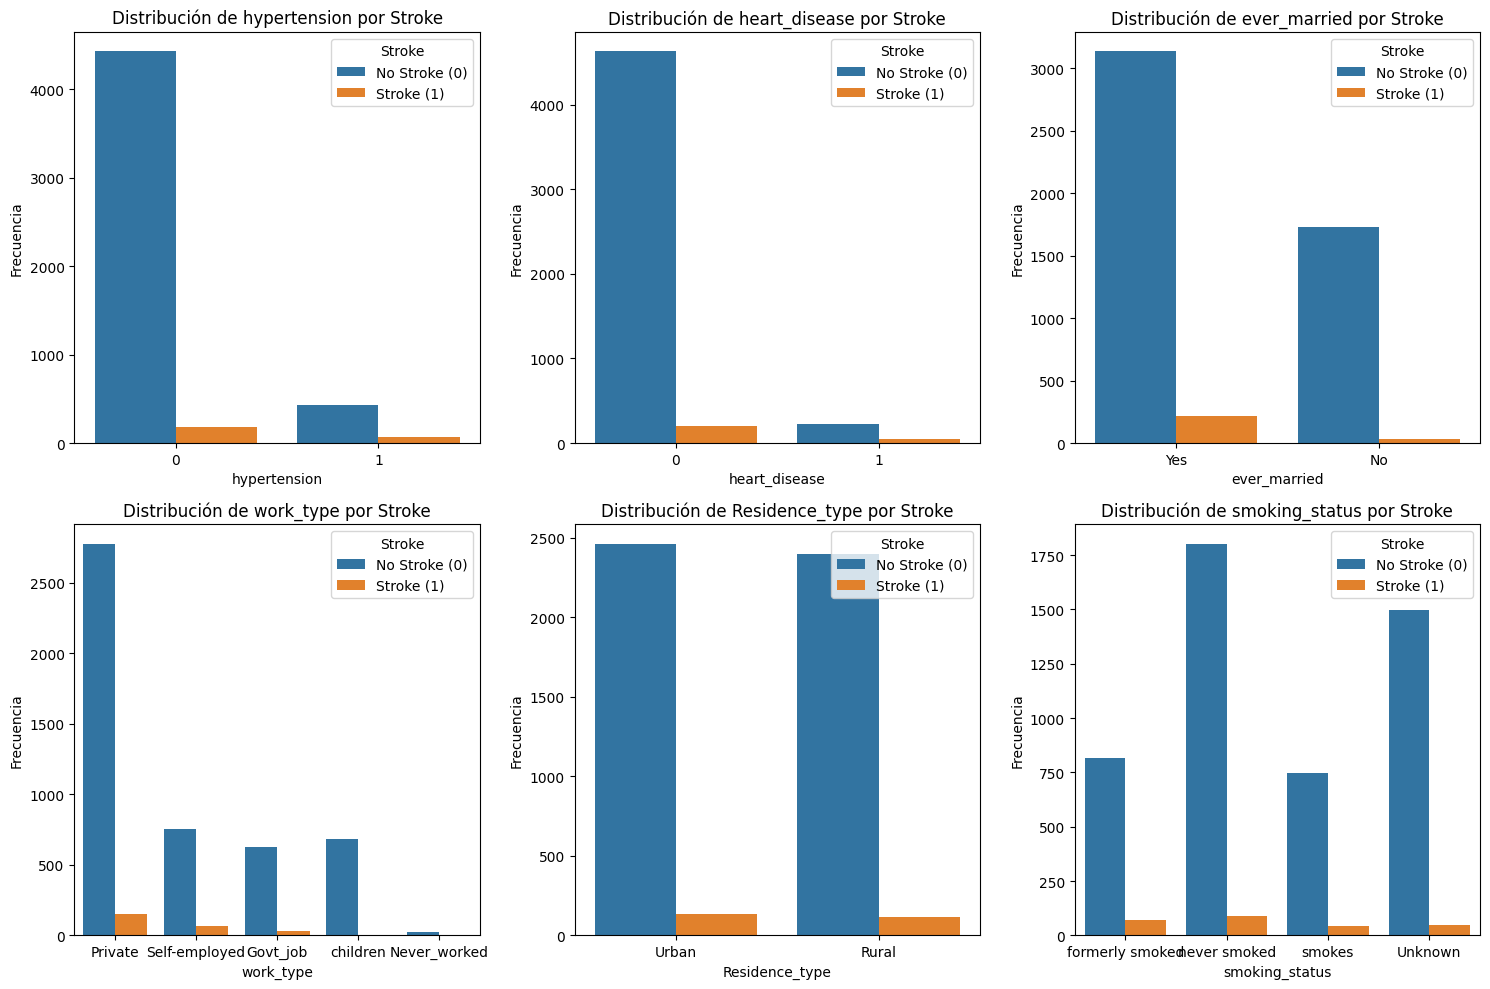

In [12]:
categorical_vars = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', ]

# Crear una malla de subplots para visualizar cada variable categórica separada por stroke
num_vars = len(categorical_vars)
cols = 3  # Número de columnas en la malla
rows = (num_vars // cols) + (num_vars % cols > 0)  # Ajustar número de filas dinámicamente

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5 * rows))
axes = axes.flatten()

# Graficar cada variable categórica separada por stroke
for i, col in enumerate(categorical_vars):
    sns.countplot(data=df, x=col, hue="stroke", ax=axes[i])
    axes[i].set_title(f"Distribución de {col} por Stroke")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(title="Stroke", labels=["No Stroke (0)", "Stroke (1)"])

# Ocultar gráficos vacíos si hay menos variables que espacios en la malla
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Debido a la inferioridad de casos de stroke =1 es dificil apreciar nada con los barplots. A primera vista, el tipo de residencia no parece influenciar. Hagamos un análisis estadístico mediante tests Xi^2.

In [13]:
# Lista de variables categóricas (excluyendo 'stroke')
categorical_vars = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Iterar sobre cada variable categórica y realizar la prueba de chi-cuadrado
for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['stroke'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    
    print(f'\nChi-cuadrado para {var} con respecto a stroke:')
    print(f'Estadístico Chi-cuadrado: {chi2}')
    print(f'Grados de libertad: {dof}')
    print(f'Valor p: {p}')
    
    if p < 0.05:
        print(f'Hay una asociación significativa entre {var} y stroke')
    else:
        print(f'No hay una asociación significativa entre {var} y stroke')


Chi-cuadrado para gender con respecto a stroke:
Estadístico Chi-cuadrado: 0.47258662884530234
Grados de libertad: 2
Valor p: 0.7895490538408245
No hay una asociación significativa entre gender y stroke

Chi-cuadrado para hypertension con respecto a stroke:
Estadístico Chi-cuadrado: 81.6053682482931
Grados de libertad: 1
Valor p: 1.661621901511823e-19
Hay una asociación significativa entre hypertension y stroke

Chi-cuadrado para heart_disease con respecto a stroke:
Estadístico Chi-cuadrado: 90.25956125843324
Grados de libertad: 1
Valor p: 2.0887845685229236e-21
Hay una asociación significativa entre heart_disease y stroke

Chi-cuadrado para ever_married con respecto a stroke:
Estadístico Chi-cuadrado: 58.923890259034195
Grados de libertad: 1
Valor p: 1.6389021142314745e-14
Hay una asociación significativa entre ever_married y stroke

Chi-cuadrado para work_type con respecto a stroke:
Estadístico Chi-cuadrado: 49.163511976675295
Grados de libertad: 4
Valor p: 5.397707801896119e-10
Hay 

Vemos que no hay una asociación estadísticamente significativa entre el ictus y el sexo y el tipo de residencia, con el resto de variables tanto categóricas como numéricas si que se presenta dicha asociación.

## Matriz de correlaciones y V de Cramer

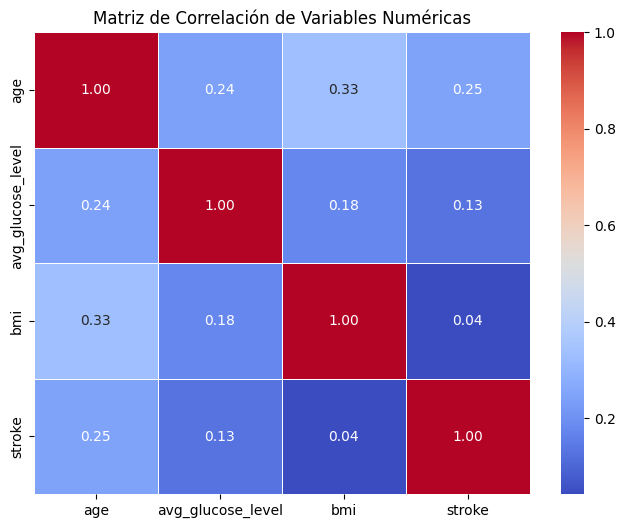

In [14]:
# Calcular matriz de correlaciones solo con variables numéricas
correlation_matrix = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].corr()

# Graficar la matriz de correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [15]:
def cramers_v(conf_matrix):
    chi2 = stats.chi2_contingency(conf_matrix)[0]
    n = np.sum(conf_matrix)
    min_dim = min(conf_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# Identificar variables categóricas (incluyendo binarias)
categorical_vars = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'gender']

# Calcular el V de Cramer para cada variable categórica con Stroke
cramers_v_results = {}

for col in categorical_vars:
    contingency_table = pd.crosstab(df[col], df['stroke'])
    v = cramers_v(contingency_table.values)
    cramers_v_results[col] = v

# Convertir resultados a DataFrame
cramers_v_df = pd.DataFrame.from_dict(cramers_v_results, orient='index', columns=['V de Cramer'])
print(cramers_v_df.sort_values(by='V de Cramer', ascending=False))

                V de Cramer
heart_disease      0.132903
hypertension       0.126371
ever_married       0.107383
work_type          0.098087
smoking_status     0.075525
Residence_type     0.014549
gender             0.009617


# Limpieza de datos
Vamos a realizar una limpieza de los datos. Primero vamos a aplicar una codificación one hot a las variables categóricas.

In [16]:
# Reemplazo de valores
df = df.replace({
    'gender': {'Male': 0, 'Female': 1, 'Other': 2},
    'ever_married': {'Yes': 0, 'No': 1},
    'work_type': {'Private': 0, 'Self-employed': 1, 'Govt_job': 2, 'children': 3, 'Never_worked': 4},
    'smoking_status': {'formerly smoked': 0, 'never smoked': 1, 'smokes': 2, 'Unknown': 3},
    'Residence_type': {'Urban': 0, 'Rural': 1},
    # 'bmi_categ':  {'Underweight':0, 'Ideal': 1, 'Overweight': 2, 'Obesity': 3},
    # 'age_categ':  {'Children':0, 'Teens': 1, 'Adults': 2,'Mid Adults': 3,'Elderly': 4},
    # 'glucose_categ':  {'Low': 0, 'Normal': 1, 'High': 2, 'Very High': 3},
})
df.head()

C:\Users\victo\AppData\Local\Temp\ipykernel_21556\3795300880.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
1,1,61.0,0,0,0,1,1,202.21,NaN,1,1
2,0,80.0,0,1,0,0,1,105.92,32.5,1,1
3,1,49.0,0,0,0,0,0,171.23,34.4,2,1
4,1,79.0,1,0,0,1,1,174.12,24.0,1,1


In [17]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Vemos que presentan 201 valores faltantes en datos del bmi. Veamos cuantos corresponden a pacientes con stroke = 1.

In [18]:
# Contar el total de casos donde 'stroke' es 1
total_stroke_1 = df['stroke'].sum()

# Mostrar el resultado
print(f"Total de registros con stroke = 1: {total_stroke_1}")


# Contar cuántos valores nulos hay en 'bmi' cuando 'stroke' es 1
missing_bmi_stroke_1 = df[df['stroke'] == 1]['bmi'].isnull().sum()

# Mostrar el resultado
print(f"Número de valores nulos en 'bmi' con stroke = 1: {missing_bmi_stroke_1}")


Total de registros con stroke = 1: 249
Número de valores nulos en 'bmi' con stroke = 1: 40


Al ser un gran número de los pacientes que presentan ictus, no es conveniente eliminar estas instancias. Vamos a realizar una imputación de los datos faltantes mediante KNN (K-Nearest Neighbors)

In [19]:
# Inicializar el imputador KNN con el número de vecinos deseado (por ejemplo, 3)
knn_imputer = KNNImputer(n_neighbors=3)

# Imputar los datos
imputed_data = knn_imputer.fit_transform(df)

# Convertir la matriz de nuevo a un DataFrame
imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

# Reemplazar los datos originales con los datos imputados
df['bmi'] = imputed_df['bmi']


df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [20]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.600000,0,1
1,1,61.0,0,0,0,1,1,202.21,35.766667,1,1
2,0,80.0,0,1,0,0,1,105.92,32.500000,1,1
3,1,49.0,0,0,0,0,0,171.23,34.400000,2,1
4,1,79.0,1,0,0,1,1,174.12,24.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,1,80.0,1,0,0,0,0,83.75,26.233333,1,0
5106,1,81.0,0,0,0,1,0,125.20,40.000000,1,0
5107,1,35.0,0,0,0,1,1,82.99,30.600000,1,0
5108,0,51.0,0,0,0,0,1,166.29,25.600000,0,0


# Entrenamiento de los modelos
Vamos a probar 5 modelos de ML para clasificación:
- Reg Logística.
- Support Vector Machine.
- Random Forest.
- XGBoost.
- Red neuronal densa.

Primero, estableceremos una Pipeline que incluirá:
- Estandarización de los datos.
- Sobremuestreo de la clase minoritaria mediante SMOTE.
- Entrenamiento de los modelos.

Para la validación de los modelos usaremos Cross Validation. Dividiremos el conjunto de datos en un 80 % train y un 20 % test que emplearemos para evaluar el mejor modelo al final.


In [21]:
target_col = 'stroke'

X = df.drop([target_col], axis=1)
y = df[target_col]

y = y.rename("stroke")

print(X.shape, y.shape)

(5110, 10) (5110,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [23]:
print("📌 Valores únicos en y_train:", np.unique(y_train))


📌 Valores únicos en y_train: [0 1]


In [24]:
for name, pipeline in pipelines.items():
    print(f"\n✅ Entrenando manualmente {name}...")
    pipeline.fit(X_train, y_train)  # 🚨 Si esto falla, el problema está en `Pipeline`



✅ Entrenando manualmente LogisticRegression...

✅ Entrenando manualmente SVC...

✅ Entrenando manualmente RandomForest...

✅ Entrenando manualmente NeuralNet...


In [25]:
# 🔹 Diccionario para almacenar métricas
metrics_results = {}

# 🔹 Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# 🔹 Ejecutar cada pipeline
for model_name, pipeline_model in pipelines.items():
    print(f"\n✅ Evaluando {model_name}...")

    metrics_results[model_name] = calculate_metrics(pipeline_model, X_train, y_train, cv)

    # 🔹 Imprimir resultados
    print(f"\n Resultados para {model_name}:")
    print(f"   Accuracy promedio: {metrics_results[model_name]['accuracy']:.4f}")
    print(f"   Precision promedio: {metrics_results[model_name]['precision']:.4f}")
    print(f"   Recall promedio: {metrics_results[model_name]['recall']:.4f}")
    print(f"   F3 Score promedio: {metrics_results[model_name]['f3_score']:.4f}")



✅ Evaluando LogisticRegression...

 Resultados para LogisticRegression:
   Accuracy promedio: 0.7434
   Precision promedio: 0.1300
   Recall promedio: 0.7692
   F3 Score promedio: 0.5154

✅ Evaluando SVC...

 Resultados para SVC:
   Accuracy promedio: 0.7718
   Precision promedio: 0.1153
   Recall promedio: 0.5692
   F3 Score promedio: 0.4081

✅ Evaluando RandomForest...

 Resultados para RandomForest:
   Accuracy promedio: 0.9203
   Precision promedio: 0.1194
   Recall promedio: 0.1077
   F3 Score promedio: 0.1086

✅ Evaluando NeuralNet...

 Resultados para NeuralNet:
   Accuracy promedio: 0.8552
   Precision promedio: 0.1702
   Recall promedio: 0.5231
   F3 Score promedio: 0.4326


## Optimización de hiperparámetros

In [26]:
# Definir la métrica de evaluación: f3 score
f3_scorer = make_scorer(fbeta_score, beta=3, zero_division=1)

In [27]:
# Directorio donde se guardarán los modelos
models_dir = "../models"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

In [28]:
# Iterar sobre cada modelo para optimizar sus hiperparámetros
for model_name, pipeline in pipelines.items():
    print(f"\nEvaluando modelo {model_name}...")
    param_grid = param_grids.get(model_name, None)
    if param_grid is None:
        print(f"No se ha definido espacio de hiperparámetros para {model_name}.")
        continue

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f3_scorer,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    print(f"Mejores parámetros para {model_name}: {best_params}")
    print(f"Mejor score: {best_score}")

    # Evaluación adicional del mejor modelo con validación cruzada
    best_model = grid_search.best_estimator_
    metrics = calculate_metrics(best_model, X_train, y_train, cv)
    print(f"Resultados de validación cruzada para {model_name}:")
    print(f"  Accuracy promedio: {metrics['accuracy']:.4f}")
    print(f"  Precision promedio: {metrics['precision']:.4f}")
    print(f"  Recall promedio: {metrics['recall']:.4f}")
    print(f"  F3 Score promedio: {metrics['f3_score']:.4f}")

    # Guardar el modelo según su arquitectura
    if model_name == "NeuralNet":
        # Para la red neuronal se guarda el pipeline completo y el estado del modelo PyTorch.
        # Se asume que el paso de la red se llama 'torch_nn'
        torch_model = best_model.named_steps['torch_nn'].model
        # Guardar el estado de la red neuronal en formato .pt
        torch.save(torch_model.state_dict(), os.path.join(models_dir, "neural_net.pt"))
        # Guardar la pipeline completa (incluyendo escalado y SMOTE) con joblib
        joblib.dump(best_model, os.path.join(models_dir, "neural_net_pipeline.joblib"))
    elif model_name == "LogisticRegression":
        joblib.dump(best_model, os.path.join(models_dir, "log_reg.joblib"))
    elif model_name == "SVC":
        joblib.dump(best_model, os.path.join(models_dir, "svc.joblib"))
    elif model_name == "RandomForest":
        joblib.dump(best_model, os.path.join(models_dir, "random_forest.joblib"))


Evaluando modelo LogisticRegression...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros para LogisticRegression: {'logreg__C': 0.001, 'logreg__class_weight': None, 'logreg__max_iter': 1000, 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}
Mejor score: 0.5434998263215897
Resultados de validación cruzada para LogisticRegression:
  Accuracy promedio: 0.7316
  Precision promedio: 0.1325
  Recall promedio: 0.8308
  F3 Score promedio: 0.5435

Evaluando modelo SVC...
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Mejores parámetros para SVC: {'svc__C': 1, 'svc__gamma': 0.001, 'svc__kernel': 'sigmoid'}
Mejor score: 0.5350994348561833
Resultados de validación cruzada para SVC:
  Accuracy promedio: 0.6835
  Precision promedio: 0.1189
  Recall promedio: 0.8769
  F3 Score promedio: 0.5351

Evaluando modelo RandomForest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores parámetros para RandomForest: {'rf__bootstrap': True, 'r

c:\Users\victo\OneDrive\Escritorio\Prueba\ex_1\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros para NeuralNet: {'torch_nn__batch_size': 64, 'torch_nn__epochs': 50, 'torch_nn__lr': 0.0001, 'torch_nn__neurons': 32, 'torch_nn__num_layers': 2}
Mejor score: 0.43599231988686843
Resultados de validación cruzada para NeuralNet:
  Accuracy promedio: 0.8518
  Precision promedio: 0.1675
  Recall promedio: 0.5333
  F3 Score promedio: 0.4368


## validación final con conjunto de test

Modelo LogisticRegression cargado exitosamente desde ../models\log_reg.joblib.
Modelo SVC cargado exitosamente desde ../models\svc.joblib.
Modelo RandomForest cargado exitosamente desde ../models\random_forest.joblib.
Modelo NeuralNet cargado exitosamente desde ../models\neural_net_pipeline.joblib.

Evaluando el modelo LogisticRegression sobre el conjunto de prueba...
Métricas para LogisticRegression:
  accuracy : 0.7622
  precision: 0.1487
  recall   : 0.7407
  f3 score : 0.5298
Matriz de confusión para LogisticRegression:
[[739 229]
 [ 14  40]]


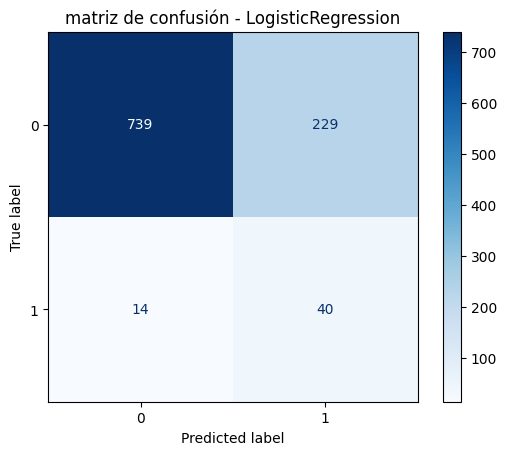


Evaluando el modelo SVC sobre el conjunto de prueba...
Métricas para SVC:
  accuracy : 0.7045
  precision: 0.1265
  recall   : 0.7778
  f3 score : 0.5134
Matriz de confusión para SVC:
[[678 290]
 [ 12  42]]


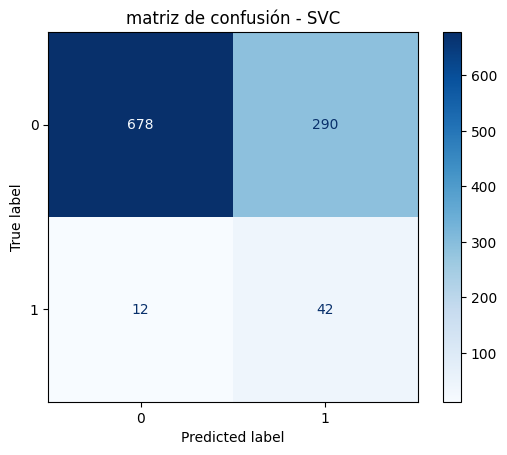


Evaluando el modelo RandomForest sobre el conjunto de prueba...
Métricas para RandomForest:
  accuracy : 0.8219
  precision: 0.1596
  recall   : 0.5556
  f3 score : 0.4451
Matriz de confusión para RandomForest:
[[810 158]
 [ 24  30]]


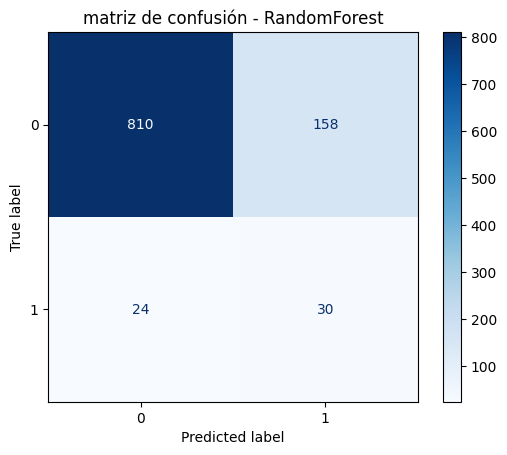


Evaluando el modelo NeuralNet sobre el conjunto de prueba...
Métricas para NeuralNet:
  accuracy : 0.8552
  precision: 0.1439
  recall   : 0.3519
  f3 score : 0.3074
Matriz de confusión para NeuralNet:
[[855 113]
 [ 35  19]]


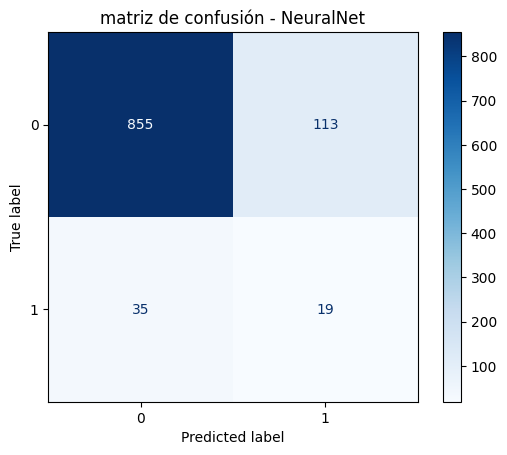

In [34]:
# Directorio donde se han guardado los modelos
models_dir = "../models"

# Diccionario que asocia cada modelo a su archivo guardado
model_files = {
    "LogisticRegression": os.path.join(models_dir, "log_reg.joblib"),
    "SVC": os.path.join(models_dir, "svc.joblib"),
    "RandomForest": os.path.join(models_dir, "random_forest.joblib"),
    "NeuralNet": os.path.join(models_dir, "neural_net_pipeline.joblib")
}

# Cargar los modelos guardados
loaded_models = {}
for model_name, file_path in model_files.items():
    if os.path.exists(file_path):
        loaded_models[model_name] = joblib.load(file_path)
        print(f"Modelo {model_name} cargado exitosamente desde {file_path}.")
    else:
        print(f"El archivo correspondiente a {model_name} no se encontró en {file_path}.")

# Evaluar cada modelo en el conjunto de prueba y calcular las métricas de rendimiento
for model_name, model in loaded_models.items():
    print(f"\nEvaluando el modelo {model_name} sobre el conjunto de prueba...")
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred, zero_division=1)
    f3 = fbeta_score(y_test, y_pred, beta=3, zero_division=1)
    
    print(f"Métricas para {model_name}:")
    print(f"  accuracy : {accuracy:.4f}")
    print(f"  precision: {precision:.4f}")
    print(f"  recall   : {recall:.4f}")
    print(f"  f3 score : {f3:.4f}")
    
    # Calcular y mostrar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    print(f"Matriz de confusión para {model_name}:\n{cm}")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    disp.plot(cmap="Blues")
    plt.title(f"matriz de confusión - {model_name}")
    plt.show()

# Conclusiones

A partir de los resultados obtenidos se concluye que, en este escenario, el modelo de regresión logística es la mejor opción por las siguientes razones:

1. **Equilibrio entre recall y precisión:**
Aunque la precisión es baja en todos los modelos, la regresión logística alcanza un recall del 74,07 % que, en combinación con su f3 score de 0,5298, indica que el modelo detecta la mayor parte de los casos de stroke (clase minoritaria). En contextos con desbalanceo de clases (unos 250 casos positivos en un total de alrededor 5000) es crucial minimizar los falsos negativos, ya que omitir un ictus puede tener consecuencias clínicas graves.
2. **Desempeño en métricas específicas para la clase de interés:**
El f3 score, que pondera el recall más que la precisión (al asignar mayor importancia a la detección de la clase positiva), es superior en el modelo de regresión logística en comparación con SVC (0,5134), RandomForest (0,4451) y NeuralNet (0,3074). Esto sugiere que, a pesar de que SVC presenta un recall ligeramente mayor (77,78 %), su precisión disminuida reduce la efectividad global medida por el f3 score.
3. **Robustez y simplicidad en escenarios con variables categóricas y datos limitados:**
La regresión logística es un modelo lineal que, en general, es más robusto y menos propenso al sobreajuste en conjuntos de datos pequeños y con alta proporción de variables categóricas. Modelos más complejos, como RandomForest o redes neuronales, pueden sobreajustarse o no generalizar adecuadamente cuando la cantidad de instancias positivas es muy limitada. Su capacidad interpretativa adicional favorece la toma de decisiones clínicas al facilitar la identificación de los factores de riesgo asociados a stroke.

En resumen, la regresión logística ofrece el mejor compromiso entre sensibilidad (recall) y especificidad, evidenciado por su superior f3 score, lo que resulta fundamental en la detección de una condición crítica en un escenario con datos desbalanceados y un número reducido de casos positivos.